In [1]:
%pip install ipympl
%matplotlib widget

Note: you may need to restart the kernel to use updated packages.


In [2]:
from enum import auto
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal
from scipy.fft import fft, fftfreq, fftshift, ifft, rfft, rfftfreq, irfft
import math

In [3]:
def transform(file_name):
    sample_rate, data = wavfile.read(file_name)

    # Check if the file is Stereo or Mono
    if len(data.shape) > 1:
        left_data = data[:, 0]
        right_data = data[:, 1]
    else:
       left_data = data
       right_data = data
    
    length=len(left_data)/2
    f = rfftfreq(len(left_data), 1/sample_rate)

    f_transform_left = rfft(left_data)
    amplitude_left = np.abs(f_transform_left) / length

    f_transform_right = rfft(right_data)
    amplitude_right = np.abs(f_transform_right) / length

    return left_data, f_transform_left, amplitude_left, right_data, f_transform_right, amplitude_right, f, sample_rate

In [4]:
def transform_mono(file_name):
    sample_rate, data = wavfile.read(file_name)
    
    # Check if the file is Stereo or Mono
    if len(data.shape) > 1:
        # It's stereo: average the left (channel 0) and right (channel 1) to make it mono
        mono_data = (data[:, 0].astype(float) + data[:, 1].astype(float)) / 2
    else:
        # It's already mono
        mono_data = data.astype(float)
    
    # Calculate FFT variables
    length = len(mono_data) / 2
    f = rfftfreq(len(mono_data), 1 / sample_rate)

    # Perform the FFT
    f_transform = rfft(mono_data)
    amplitude = np.abs(f_transform) / length

    return mono_data, f_transform, amplitude, f, sample_rate

In [5]:
def plot(x, y, title, xlabel, ylabel, xmax=25000):
    plt.figure(figsize=(10, 4))
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    plt.plot(x, y)
    
    
    if xmax != 25000:
        plt.xlim(0, xmax)

    plt.tight_layout()
    plt.show()


In [6]:
def plot_freqs(x1, y1, x2, y2, x3, y3, x4, y4, title, xlabel, ylabel, xmax=25000):
    plt.figure(figsize=(10, 4))
    plt.title(title)
    plt.ylabel(ylabel)
    plt.xlabel(xlabel)
    
    plt.plot(x1, y1, label='Original', color='Blue')
    plt.plot(x2, y2, label='Room Noise', color='orange')
    plt.plot(x3, y3, label='Phone Recorded', color='gray')
    plt.plot(x4, y4, label='Alexa Recorded', color='black')
    
    if xmax != 25000:
        plt.xlim(0, xmax)

    plt.legend(loc="upper right")
    plt.tight_layout()
    plt.show()

C:\Users\eranm\AppData\Local\Temp\ipykernel_37316\1984806328.py:2: WavFileWarning: Reached EOF prematurely; finished at 45539519 bytes, expected 4294967303 bytes from header.
  sample_rate, data = wavfile.read(file_name)


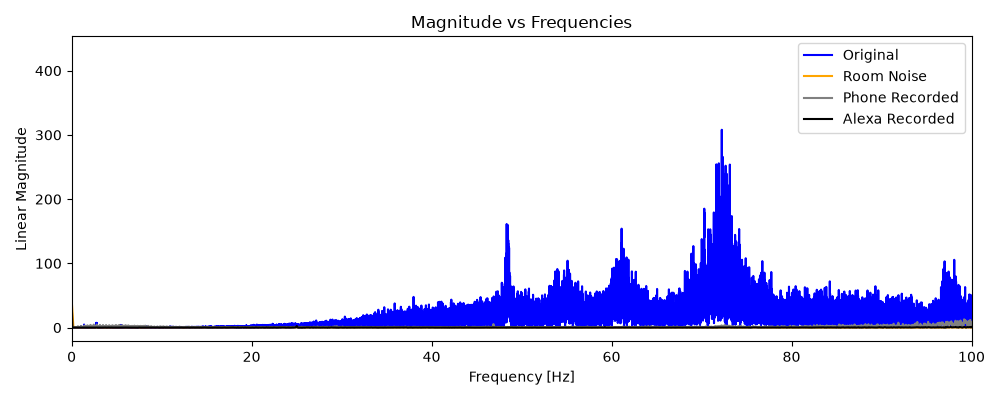

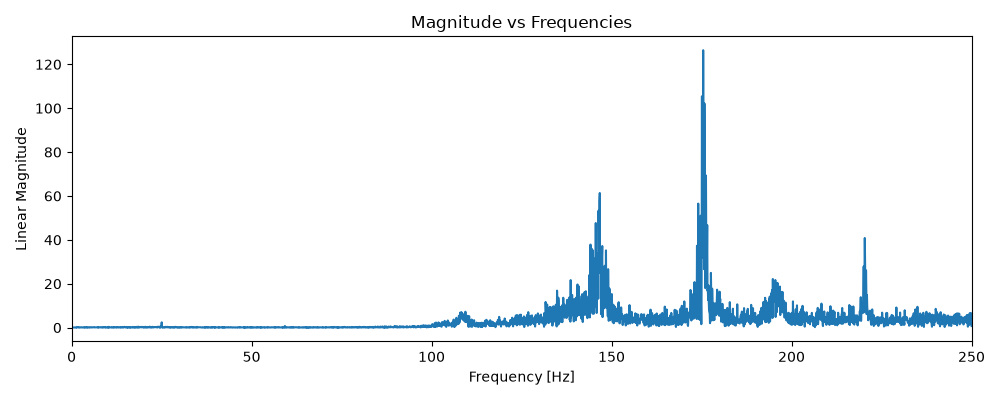

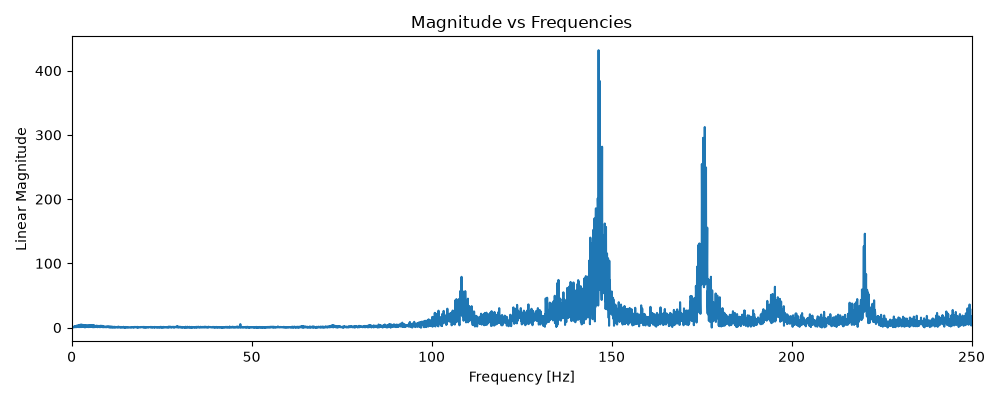

In [7]:
mono_data, f_transform, amplitude, f, sample_rate = transform_mono("come_together.wav")
room_data, room_f_transform, room_amplitude, room_f, room_sample_rate = transform_mono('room.wav')
phone_data, phone_f_transform, phone_amplitude, phone_f, phone_sample_rate = transform_mono('phone_recording.wav')
alexa_data, alexa_f_transform, alexa_amplitude, alexa_f, alexa_sample_rate = transform_mono('alexa_recording.wav')
plot_freqs(f, amplitude, room_f, room_amplitude, phone_f, phone_amplitude, alexa_f, alexa_amplitude, 'Magnitude vs Frequencies', 'Frequency [Hz]', 'Linear Magnitude', 100)
plot(alexa_f, alexa_amplitude, 'Magnitude vs Frequencies', 'Frequency [Hz]', 'Linear Magnitude', 250)
plot(phone_f, phone_amplitude, 'Magnitude vs Frequencies', 'Frequency [Hz]', 'Linear Magnitude', 250)

C:\Users\eranm\AppData\Local\Temp\ipykernel_37316\1984806328.py:2: WavFileWarning: Reached EOF prematurely; finished at 45539519 bytes, expected 4294967303 bytes from header.
  sample_rate, data = wavfile.read(file_name)


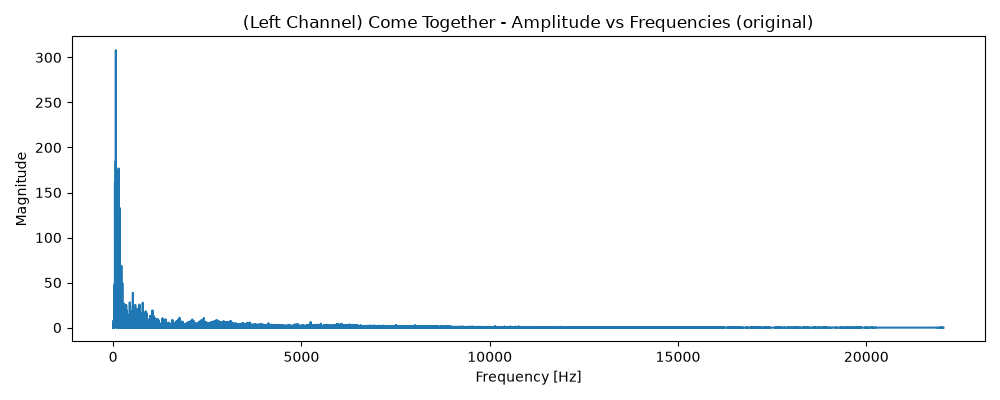

In [8]:
#Convert song to mono and place it in the left channel
left_data, left_f_transform, left_amplitude, f, sample_rate = transform_mono("come_together.wav")
plot(f, left_amplitude,  '(Left Channel) Come Together - Amplitude vs Frequencies (original)', 'Frequency [Hz]', 'Magnitude')


In [9]:
def remove_dc_offset(f_transform):
    f_transform[0] = 0
    amplitude = np.abs(f_transform) / len(f_transform)
    return amplitude, f_transform

In [10]:
def adjust_frequencies(sample_rate, f_transform, f, min_freq):
    #35Hz to 20kHz for JBL Bar500; 200Hz to 16kHz for iPhone (but just dealing with HPF); 100Hz to 20kHz for Amazon Echo Dot Gen. 2
    #find indices by sampling frequency/#samples * frequency
    length = f_transform.size
    delta_f = sample_rate/((length-1)*2)
    min_freq_index = int(min_freq/delta_f)+1

    # #apply HPF to frequencies below the cutoff
    # #nth order attenuation has slope 6n(dB/octave)
    # b, a = signal.butter(N=5, Wn=min_freq, btype='highpass', fs=sample_rate, output='ba')
    # _, h = signal.freqz(b, a, worN=f, fs=sample_rate)
    # f_transform = f_transform * h

    #apply hard hpf
    f_transform[:min_freq_index] = 0
    
    
    amplitude = np.abs(f_transform) / length
    return amplitude, f_transform

In [11]:
def amplify_frequencies(sample_rate, f_transform):
    #200Hz to #20kHz
    #find indices by sampling frequency/#samples * frequency
    length = f_transform.size
    delta_f = sample_rate/((length-1)*2)
    min_freq_index = int(200/delta_f)+1
    
    for i in range(min_freq_index):
        f_transform[i] *= 2
    
    amplitude = np.abs(f_transform) / length
    return amplitude, f_transform

In [ ]:
def missing_fundamental(sample_rate, f_transform, min_freq):
    right = np.zeros_like(f_transform)
    length = f_transform.size
    delta_f = sample_rate/((length-1)*2)
    min_audible_index = int(40/delta_f)+1
    min_freq_index = int(min_freq/delta_f)+1

    for i in range(min_audible_index, min_freq_index):
        #minimum harmonic that is >= min_freq_index
        # n = math.ceil(min_freq/(i*delta_f))
        # n = 2
        # n_index = n*i
        # n_p1_index = (n+1)*i
        # n_p2_index = (n+2)*i
        
        # right[n_index] += (f_transform[i] * 0.75)
        # right[n_p1_index] += (f_transform[i] * 0.5)
        # right[n_p2_index] += (f_transform[i] * 0.25)

        harmonics_added = 0
        n = 2
        while harmonics_added < 3:
            n_index = n*i
            if right[n_index] == 0:
                right[n_index] = (f_transform[i] / n)
                harmonics_added += 1
            n += 1

    # for i in range(min_audible_index, min_freq_index):
    #     right[i] = f_transform[i]

    amplitude = np.abs(right) / length
    return amplitude, right


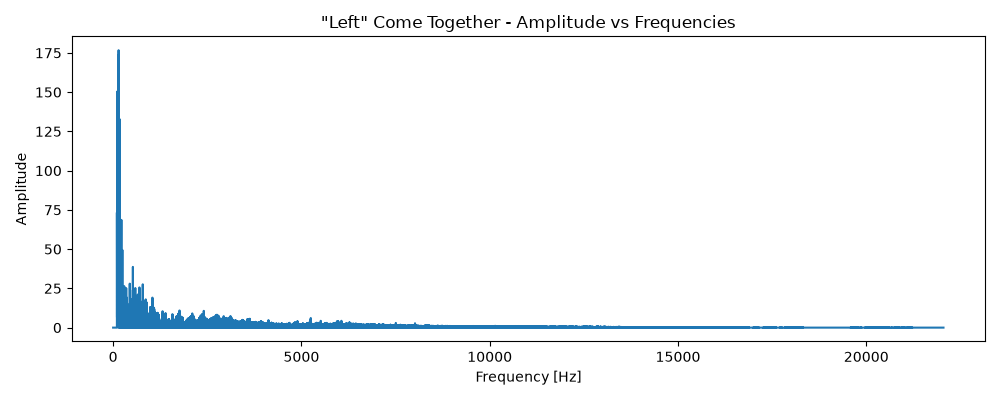

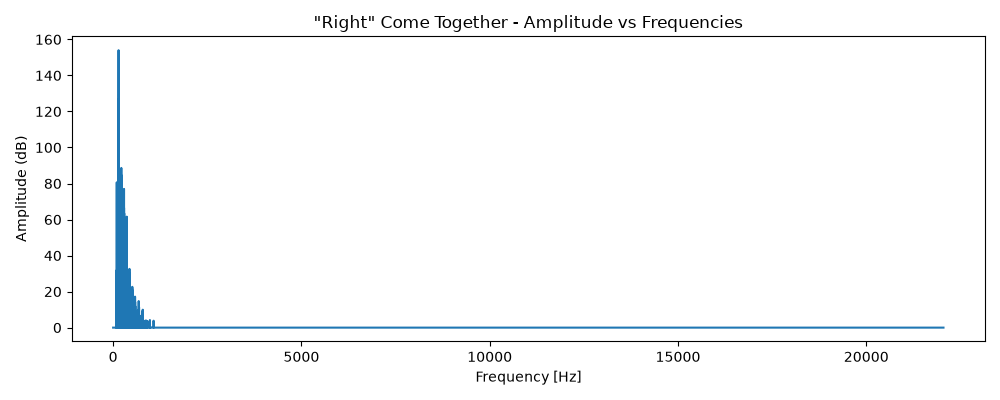

In [13]:
right_amplitude, right = missing_fundamental(sample_rate, left_f_transform.copy(), 100)
left_amplitude_new, left = adjust_frequencies(sample_rate, left_f_transform.copy(), f, 100)

plot(f, left_amplitude_new,  '"Left" Come Together - Amplitude vs Frequencies', 'Frequency [Hz]', 'Amplitude')
plot(f, right_amplitude,  '"Right" Come Together - Amplitude vs Frequencies', 'Frequency [Hz]', 'Amplitude (dB)')

In [14]:
def inverse_transform(left, right, sample_rate, output_filename):
    # reconstructed_left = irfft(left)
    # reconstructed_right = irfft(right)
  
    # reconstructed_real = np.stack((reconstructed_left, reconstructed_right), axis=1)
    # audio_data_int16 = np.int16(np.clip(reconstructed_real, -32768, 32767))

    reconstructed_left = irfft(right)
    reconstructed_right = irfft(right)
  
    reconstructed_real = np.stack((reconstructed_left, reconstructed_right), axis=1)
    audio_data_int16 = np.int16(np.clip(reconstructed_real, -32768, 32767))
    
    wavfile.write(output_filename, sample_rate, audio_data_int16)

    return audio_data_int16

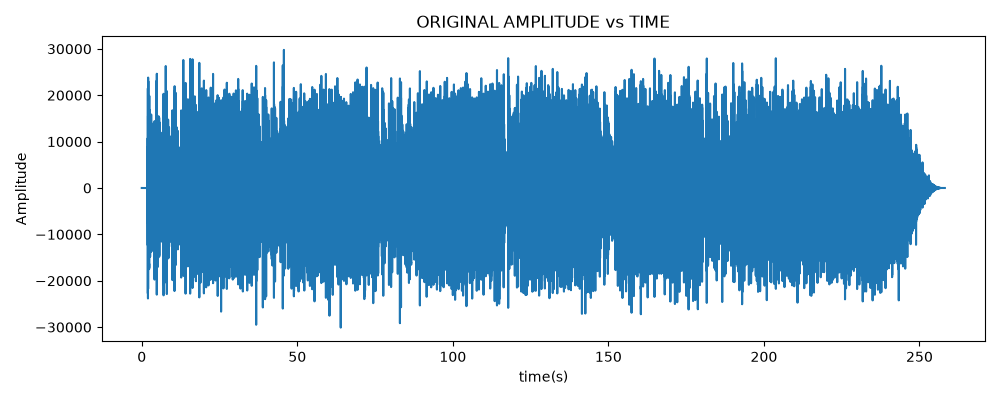

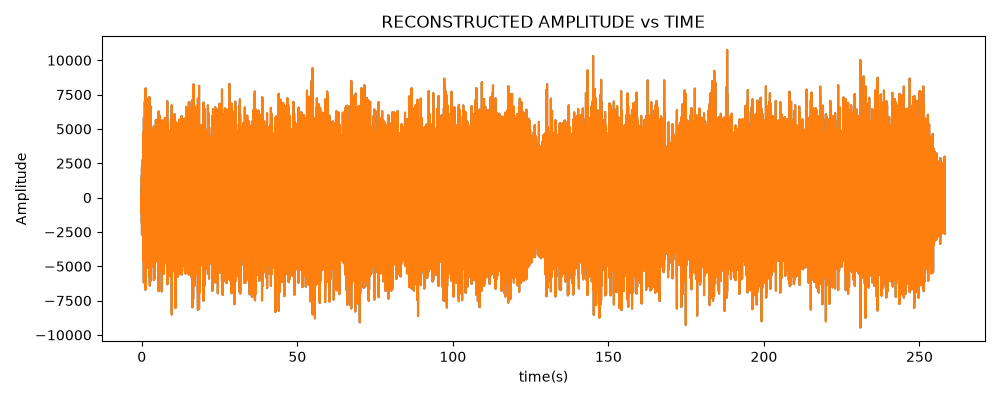

In [15]:
reconstructed_data = inverse_transform(left, right, sample_rate, 'come_together_lows_harmonic.wav')
original_data = left_data

duration = len(original_data) / sample_rate
time = np.linspace(0.0, duration, num=len(original_data))

dbfs_ref = 32768.0
plot(time, original_data, 'ORIGINAL AMPLITUDE vs TIME', 'time(s)', 'Amplitude')
plot(time, reconstructed_data, 'RECONSTRUCTED AMPLITUDE vs TIME', 'time(s)', 'Amplitude')